# Time Series Commodities Modeling In Python 

## <u>About the datasets

This reports consist of 3 Datafile:
1. Total Commodities Harvest Data: Includes all harvest production data of various crops that plays a role in the production of Biofuels.
2. Combine Commodity Prices: Includes the weekly commodity prices of various biofuels and crops oil
3. EuETS and Carbon Taxes Prices: Shows green tariffs imposed by each country over the years

Data collected will mainly be focus from the **year 2007 to 2023**

In [1]:
#pip install geopandas

In [2]:
#!pip install statsmodels

In [3]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message="Coordinate descent without L1 regularization*")

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point

### <U>The commodity harvest dataset

In [5]:
harvest=pd.read_csv('Total Commodities harvest data.csv')
harvest.info()

<class 'pandas.DataFrame'>
RangeIndex: 1065 entries, 0 to 1064
Data columns (total 34 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area Code        1065 non-null   int64  
 1   Area Code (M49)  1065 non-null   str    
 2   Area             1065 non-null   str    
 3   Item Code        1065 non-null   int64  
 4   Item Code (CPC)  1065 non-null   str    
 5   Item             1065 non-null   str    
 6   Element Code     1065 non-null   int64  
 7   Element          1065 non-null   str    
 8   Unit             1065 non-null   str    
 9   2000             928 non-null    float64
 10  2001             929 non-null    float64
 11  2002             929 non-null    float64
 12  2003             933 non-null    float64
 13  2004             935 non-null    float64
 14  2005             936 non-null    float64
 15  2006             938 non-null    float64
 16  2007             929 non-null    float64
 17  2008             930 non-

### Preparing the Total Commodities harvest dataset for Modelling

In [6]:
# Transpose individual year column into 1 column called Year

# Identify year columns (they are numeric column names)
year_cols = [col for col in harvest.columns if col.isdigit()]

# Melt the dataframe
harvest_long = pd.melt(
    harvest,
    id_vars=[col for col in harvest.columns if col not in year_cols],
    value_vars=year_cols,
    var_name='Year',
    value_name='Total Commodities Production'
)

# Drop Null Values as in some years not all countries declared a harvest or some countries just don't grow the crops

harvest_long = harvest_long.dropna(subset=['Total Commodities Production'])

# Convert Year into datetime
harvest_long['Year']=harvest_long['Year'].astype(int)
harvest_long.head()


,Area Code,Area Code (M49),Area,Item Code,Item Code (CPC),Item,Element Code,Element,Unit,Year,Total Commodities Production
0,2,'004,Afghanistan,156,'01802,Sugar cane,5510,Production,t,2000,38000.0
1,7,'024,Angola,156,'01802,Sugar cane,5510,Production,t,2000,350000.0
3,9,'032,Argentina,156,'01802,Sugar cane,5510,Production,t,2000,18400000.0
4,10,'036,Australia,156,'01802,Sugar cane,5510,Production,t,2000,38164688.0
5,12,'044,Bahamas,156,'01802,Sugar cane,5510,Production,t,2000,62500.0


### <u> The Combine Commodity Prices datasets

In [7]:
fuel_price=pd.read_csv('combined commodity prices.csv')
# Convert Date column to datetime
fuel_price['Date']=pd.to_datetime(fuel_price['Date'])
# convert Year column to String
fuel_price['Year']=fuel_price['Year'].astype(int)
# Converting all % change columns into float
fuel_price.columns = fuel_price.columns.str.strip()
percent_cols = [
    'Brent_Change %',
    'Ethanol_Change %',
    'Biodiesel_Price IA-USDA %change',
    'Biodiesel_Price OPIS % change',
    'Soybean Oil_Price  % change',
    'Methanol Price % change',
    'Return Over Operating Costs % change',
    'Cost of Soybean Oil % change',
    'Other Operating Costs % change',
    'Price_DBI % change',
    'Price_DBI'

]

fuel_price[percent_cols] = (
    fuel_price[percent_cols]
        .replace('%', '', regex=True)
        .apply(pd.to_numeric, errors='coerce')
        .astype(float)
)
fuel_price.info()

<class 'pandas.DataFrame'>
RangeIndex: 979 entries, 0 to 978
Data columns (total 22 columns):
 #   Column                                                Non-Null Count  Dtype         
---  ------                                                --------------  -----         
 0   Date                                                  979 non-null    datetime64[us]
 1   Year                                                  979 non-null    int64         
 2   Brent_Price                                           979 non-null    float64       
 3   Brent_Change %                                        979 non-null    float64       
 4   Ethanol_Price                                         979 non-null    float64       
 5   Ethanol_Change %                                      979 non-null    float64       
 6   Biodiesel_Price ($/gallon) IA-USDA                    979 non-null    float64       
 7   Biodiesel_Price IA-USDA %change                       979 non-null    float64       
 8   B

In [8]:
# Sort in Descending Order so We see the latest Value First
fuel_price=fuel_price.sort_values(by='Date',ascending= False)
fuel_price.head()

,Date,Year,Brent_Price,Brent_Change %,Ethanol_Price,Ethanol_Change %,Biodiesel_Price ($/gallon) IA-USDA,Biodiesel_Price IA-USDA %change,Biodiesel_Price ($/gallon) OPIS,Biodiesel_Price OPIS % change,...,Methanol Price ($/metric ton),Methanol Price % change,Return Over Operating Costs ($/gallon),Return Over Operating Costs % change,Cost of Soybean Oil ($/gallon),Cost of Soybean Oil % change,Other Operating Costs (net of co-products; $/gallon),Other Operating Costs % change,Price_DBI,Price_DBI % change
978,2026-02-13,2026,67.75,-0.44,1.745,1.75,2.81,0.0,4.055,6.0,...,925,0.0,-1.994573,8.0,4.24004,3.0,0.564532,0.0,2083.0,8.0
977,2026-02-06,2026,68.05,-3.73,1.715,1.78,2.81,0.0,3.835,-2.0,...,925,9.0,-1.854733,8.0,4.10020,3.0,0.564532,5.0,1923.0,-10.0
976,2026-01-30,2026,70.69,8.64,1.685,-1.17,2.81,0.0,3.900,4.0,...,851,0.0,-1.709717,1.0,3.98088,0.0,0.538836,0.0,2148.0,22.0
975,2026-01-23,2026,65.07,1.47,1.705,4.28,2.81,0.0,3.755,8.0,...,851,0.0,-1.690717,-1.0,3.96188,0.0,0.538836,0.0,1762.0,12.0
974,2026-01-16,2026,64.13,1.25,1.635,-4.66,2.81,0.0,3.475,3.0,...,851,0.0,-1.701357,21.0,3.97252,8.0,0.538836,0.0,1567.0,-7.0


### <u> The EUETS & Carbon Datasets

### Preparing the EuEts and Carbon Tax data for Modelling

In [9]:
# Importing the dataset

euets=pd.read_csv('EUETS and Carbox Taxes Prices_country.csv')

# Transpose individual year column into 1 column called Year

# Identify year columns (they are numeric column names)
euets_year_cols = [col for col in euets.columns if col.isdigit()]

# Melt the dataframe
euets = pd.melt(
    euets,
    id_vars=[col for col in euets.columns if col not in euets_year_cols],
    value_vars=euets_year_cols,
    var_name='Year',
    value_name='Carbon Price'
)

#  We will drop the NA in these values as the Nan are missing data about carbon price because:
#  the country have either did not implement any form of carbon tax or 
# Emission Trading schemes during that year as such we can Ignore the Null values

euets = euets.dropna(subset=['Carbon Price'])

# Convert Year into datetime
euets['Year']=euets['Year'].astype(int)
euets_year=euets.groupby(['Year', 'Instrument Type'])['Carbon Price'].sum().reset_index()

euets_year = euets_year[euets_year['Year'].between(2007, 2024)]
euets_year.head()

,Year,Instrument Type,Carbon Price
15,2007,Carbon tax,279.742561
16,2007,ETS,14.262561
17,2008,Carbon tax,377.439191
18,2008,ETS,49.088968
19,2009,Carbon tax,317.931718


### Pivoting the table to get Carbon Tax and ETS Prices in Column Format

In [10]:
euets_year = euets_year.pivot(
    index='Year',
    columns='Instrument Type',
    values='Carbon Price'
).reset_index()
euets_year.head()

Instrument Type,Year,Carbon tax,ETS
0,2007,279.742561,14.262561
1,2008,377.439191,49.088968
2,2009,317.931718,31.285077
3,2010,425.717849,46.891563
4,2011,521.498765,142.147740


### <u>Combining The Tables for data modeling

First, let's merge the EUETS table with the combine fuel prices datasets:

In [11]:
# Merging the Euets table by year with the fuel prices 
merged_ets_fuel=pd.merge(fuel_price,euets_year,
                         on='Year', how= 'left'
                        
)

merged_ets_fuel = merged_ets_fuel[merged_ets_fuel['Year'].between(2007, 2024)]
merged_ets_fuel.head()

,Date,Year,Brent_Price,Brent_Change %,Ethanol_Price,Ethanol_Change %,Biodiesel_Price ($/gallon) IA-USDA,Biodiesel_Price IA-USDA %change,Biodiesel_Price ($/gallon) OPIS,Biodiesel_Price OPIS % change,...,Return Over Operating Costs ($/gallon),Return Over Operating Costs % change,Cost of Soybean Oil ($/gallon),Cost of Soybean Oil % change,Other Operating Costs (net of co-products; $/gallon),Other Operating Costs % change,Price_DBI,Price_DBI % change,Carbon tax,ETS
59,2024-12-27,2024,74.17,1.69,1.745,0.17,3.89,0.0,3.97,1.0,...,0.355001,0.0,3.00276,0.0,0.532239,0.0,990.0,0.0,1279.639767,458.075497
60,2024-12-20,2024,72.94,-2.08,1.742,0.40,3.89,0.0,3.95,-5.0,...,0.355001,181.0,3.00276,-7.0,0.532239,0.0,990.0,-6.0,1279.639767,458.075497
61,2024-12-13,2024,74.49,4.74,1.735,0.29,3.89,0.0,4.16,3.0,...,0.126241,-18.0,3.23152,1.0,0.532239,0.0,1051.0,-10.0,1279.639767,458.075497
62,2024-12-06,2024,71.12,-2.50,1.730,1.23,3.89,0.0,4.03,1.0,...,0.153601,-18.0,3.20416,1.0,0.532239,3.0,1167.0,-14.0,1279.639767,458.075497
63,2024-11-29,2024,72.94,-2.97,1.709,-0.06,3.89,0.0,3.99,-2.0,...,0.187402,0.0,3.18668,0.0,0.515918,0.0,1354.0,-12.0,1279.639767,458.075497


## Merge **merged_ets_fuel** With harvest data on year 

In [12]:
# Get the World Data from harvest data set
harvest_world = harvest_long[harvest_long['Area'] == 'World']

# Pivot so each commodity is a column
harvest_world = harvest_world.pivot(
    index='Year',
    columns='Item',
    values='Total Commodities Production'
).reset_index()
# Rounding them to 2 dp 
pd.options.display.float_format = '{:,.2f}'.format
harvest_world.head()

Item,Year,"Cereals, primary",Maize (corn),Oil of maize,Palm oil,Soya bean oil,Soya beans,Sugar cane
0,2000,"2,057,902,919.00","591,934,795.40","1,944,820.54","22,227,769.00","25,626,339.54","161,312,583.20","1,252,958,244.00"
1,2001,"2,106,830,520.00","614,986,879.10","1,915,982.71","24,835,758.00","27,718,296.19","177,020,742.80","1,257,317,245.00"
2,2002,"2,037,238,425.00","603,501,069.10","1,943,530.59","26,136,149.00","29,047,402.83","180,950,733.10","1,326,715,242.00"
3,2003,"2,098,750,767.00","644,601,934.70","1,995,811.42","28,677,264.00","30,837,212.29","190,573,528.00","1,371,603,592.00"
4,2004,"2,277,130,239.00","728,982,520.20","1,967,170.89","30,062,437.00","30,704,636.23","205,548,134.40","1,333,058,729.00"


In [13]:
# Merging the Euets table by year with the fuel prices 
final_df=pd.merge(merged_ets_fuel,harvest_world,
                         on='Year', how= 'left'
                        
)

final_df = final_df[final_df['Year'].between(2007, 2024)]
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 31 columns):
 #   Column                                                Non-Null Count  Dtype         
---  ------                                                --------------  -----         
 0   Date                                                  920 non-null    datetime64[us]
 1   Year                                                  920 non-null    int64         
 2   Brent_Price                                           920 non-null    float64       
 3   Brent_Change %                                        920 non-null    float64       
 4   Ethanol_Price                                         920 non-null    float64       
 5   Ethanol_Change %                                      920 non-null    float64       
 6   Biodiesel_Price ($/gallon) IA-USDA                    920 non-null    float64       
 7   Biodiesel_Price IA-USDA %change                       920 non-null    float64       
 8   B

### Its time to do modeling with our final data sets **final_df**

In [14]:
# Y_target Is only to separate the y variable from the x variable
y_target_biodiesel = final_df['Biodiesel_Price ($/gallon) IA-USDA']

final_variables = final_df.drop(
    columns=[
        
        'Biodiesel_Price IA-USDA %change',
        'Biodiesel_Price ($/gallon) OPIS',
        'Biodiesel_Price OPIS % change'
    ]
)
final_variables.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 28 columns):
 #   Column                                                Non-Null Count  Dtype         
---  ------                                                --------------  -----         
 0   Date                                                  920 non-null    datetime64[us]
 1   Year                                                  920 non-null    int64         
 2   Brent_Price                                           920 non-null    float64       
 3   Brent_Change %                                        920 non-null    float64       
 4   Ethanol_Price                                         920 non-null    float64       
 5   Ethanol_Change %                                      920 non-null    float64       
 6   Biodiesel_Price ($/gallon) IA-USDA                    920 non-null    float64       
 7   Soybean Oil_Price (cents/lb)                          920 non-null    float64       
 8   S

### Correlation of variables

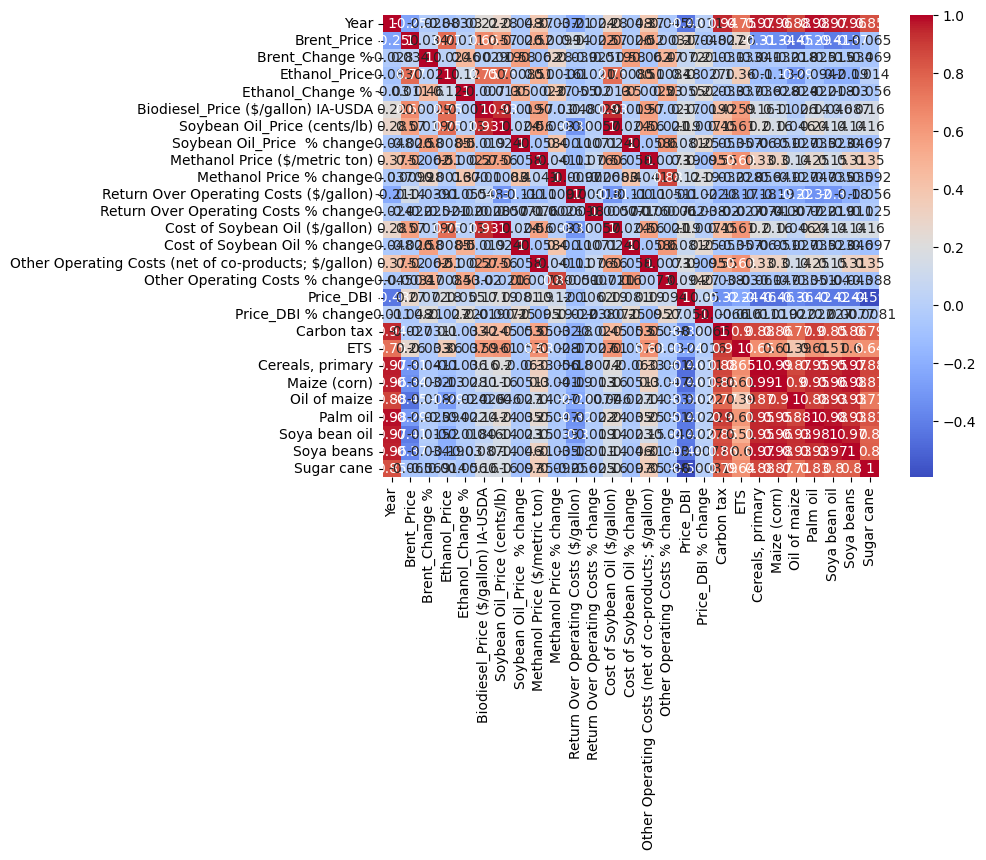

In [15]:


corr = final_variables.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [16]:
import numpy as np

corr_matrix = final_variables.corr().abs()

# Create mask for upper triangle
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find high correlations
high_corr = (
    upper.stack()
         .sort_values(ascending=False)
)

print(high_corr[high_corr > 0.8])

Soybean Oil_Price  % change         Cost of Soybean Oil % change                           1.00
Soybean Oil_Price (cents/lb)        Cost of Soybean Oil ($/gallon)                         1.00
Methanol Price ($/metric ton)       Other Operating Costs (net of co-products; $/gallon)   1.00
Date                                Year                                                   1.00
Cereals, primary                    Maize (corn)                                           0.99
Year                                Palm oil                                               0.98
Date                                Palm oil                                               0.98
Maize (corn)                        Soya beans                                             0.98
Palm oil                            Soya bean oil                                          0.98
Cereals, primary                    Soya beans                                             0.97
Year                                Cere

## Evaluation of Correlated Variables

Correlation analysis revealed that several explanatory variables — particularly agricultural production indicators — exhibit high pairwise correlation. This is especially evident among crop-related variables such as cereals, maize, soybean derivatives, and related feedstock measures. However, high correlation does not imply that these variables represent identical data sources or redundant information.

In commodity markets, structural interdependence is expected. Agricultural outputs, feedstock prices, and energy inputs are economically linked through supply chains and substitution effects. Therefore, strong correlation among these variables reflects real-world economic structure rather than statistical error. From an economic perspective, such interdependence is logical and consistent with market dynamics.

Given that the objective of this project is to model real-world biodiesel price formation, it would be inappropriate to remove variables solely on the basis of high correlation scores. 

**<u> Artificially forcing independence among economically connected variables may instead:**</u>

- Distort the structural representation of the real world economic system

- Omit meaningful shared signal

- Introduce omitted variable bias

- Reduce predictive performance

**<u> It is also important to emphasize that correlation does not imply redundancy. Two highly correlated variables may still:**</u>

- Contain incremental predictive signal

- Improve model performance jointly

- Capture different transmission mechanisms within the commodity system

For example, agricultural production captures supply-side fundamentals, while input cost variables capture pricing transmission effects. Although related, these represent distinct economic channels.

**<u> Considerations for Model Selection:**</u>

However, the presence of multicollinearity does carry important methodological implications. Models that rely on pure coefficient interpretability — such as Ordinary Least Squares (OLS) without regularization — may produce unstable, inflated, or highly sensitive coefficient estimates in environments where predictors are strongly correlated. For this reason, alternative modeling approaches that are more robust to multicollinearity were prioritised. Regularized linear models such as Ridge regression were particularly appropriate, as L2 regularization stabilizes coefficient estimates while preserving the shared economic signal embedded in correlated variables. In addition, tree-based ensemble methods and SARIMAX specifications were explored as alternative predictive frameworks, given their structural flexibility and reduced sensitivity to linear dependency among features.

In summary, correlated variables were retained intentionally to preserve economic realism and predictive strength, while model selection was adapted to appropriately handle multicollinearity.

In [17]:
X = final_variables.select_dtypes(include='number')
X = X.dropna()

# compute vif
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_df = pd.DataFrame()
vif_df['Variable'] = X.columns
vif_df['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_df = vif_df.sort_values(by='VIF', ascending=False)

print(vif_df)

                                             Variable          VIF
6                        Soybean Oil_Price (cents/lb)          inf
7                         Soybean Oil_Price  % change          inf
12                     Cost of Soybean Oil ($/gallon)          inf
13                       Cost of Soybean Oil % change          inf
8                       Methanol Price ($/metric ton) 1,329,167.54
14  Other Operating Costs (net of co-products; $/g... 1,327,914.78
5                  Biodiesel_Price ($/gallon) IA-USDA   163,063.57
10             Return Over Operating Costs ($/gallon)    20,682.56
0                                                Year       279.49
21                                       Maize (corn)       171.96
20                                   Cereals, primary       125.91
23                                           Palm oil       101.88
24                                      Soya bean oil       101.38
25                                         Soya beans        7

c:\Users\user\anaconda3\envs\py312\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


## Dropping of Unimportant Correlated Columns

In [18]:
final_variables = final_variables.drop(
    columns=[
        
        'Cost of Soybean Oil % change',
        'Soybean Oil_Price  % change',
        'Other Operating Costs % change',
        'Methanol Price % change',
        'Brent_Change %',
        'Ethanol_Change %',
        'Price_DBI % change',
        'Return Over Operating Costs % change',
        'Soybean Oil_Price (cents/lb)',
        'Year',
        'Return Over Operating Costs ($/gallon)',
        'Other Operating Costs (net of co-products; $/gallon)'
       

        
        

        
    ]
)

In [19]:
for col in final_variables.columns:
    print(repr(col))

'Date'
'Brent_Price'
'Ethanol_Price'
'Biodiesel_Price ($/gallon) IA-USDA'
'Methanol Price ($/metric ton)'
'Cost of Soybean Oil ($/gallon)'
'Price_DBI'
'Carbon tax'
'ETS'
'Cereals, primary'
'Maize (corn)'
'Oil of maize'
'Palm oil'
'Soya bean oil'
'Soya beans'
'Sugar cane'


In [20]:
# Only numeric predictors
X_numeric = final_variables.select_dtypes(include='number').dropna()

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_df = pd.DataFrame()
vif_df["Variable"] = X_numeric.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_numeric.values, i)
    for i in range(X_numeric.shape[1])
]

vif_df = vif_df.sort_values(by="VIF", ascending=False)

print(vif_df)

                              Variable      VIF
8                     Cereals, primary 9,313.38
14                          Sugar cane 4,652.40
9                         Maize (corn) 3,842.53
12                       Soya bean oil 2,855.73
13                          Soya beans 2,249.99
11                            Palm oil 1,067.58
10                        Oil of maize   674.66
6                           Carbon tax   365.26
2   Biodiesel_Price ($/gallon) IA-USDA   170.36
4       Cost of Soybean Oil ($/gallon)   138.17
1                        Ethanol_Price    93.11
0                          Brent_Price    90.07
3        Methanol Price ($/metric ton)    53.08
7                                  ETS    44.27
5                            Price_DBI     6.04


# <u>Variance Inflation Factor (VIF) Analysis</u>

Variance Inflation Factor (VIF) was computed to assess the degree of multicollinearity among explanatory variables. VIF measures how much the variance of a regression coefficient is inflated due to correlation with other predictors. Values exceeding 10 are generally considered indicative of severe multicollinearity.

Earlier, Ccrrelation matrix was used to screen for strong pairwise relationships and to confirm structural linkage across commodity variables.

In this component, the VIF was used to quantify multicollinearity severity in a regression context, showing how much predictors overlap when considered jointly.

The results revelaed extremely high VIF values among agricultural production variables such as Cereals (9,313), Sugar Cane (4,652), and Maize (3,842). This reflects strong structural interdependence among crop-related variables, which is economically intuitive given their shared supply-chain and global production dynamics.

While high VIF values can destabilize coefficient estimates in Ordinary Least Squares (OLS) regression, they do not necessarily impair predictive performance. Rather, they signal that coefficients may not be individually interpretable in isolation. Given the objective of this project is predictive modeling rather than causal inference, and given the use of regularized approaches such as Ridge regression, these correlated variables were retained to preserve system-level information.

In [21]:
final_variables.head()

,Date,Brent_Price,Ethanol_Price,Biodiesel_Price ($/gallon) IA-USDA,Methanol Price ($/metric ton),Cost of Soybean Oil ($/gallon),Price_DBI,Carbon tax,ETS,"Cereals, primary",Maize (corn),Oil of maize,Palm oil,Soya bean oil,Soya beans,Sugar cane
0,2024-12-27,74.17,1.75,3.89,832,3.00,990.00,"1,279.64",458.08,"3,133,222,741.00","1,218,205,574.00",NaN,NaN,NaN,"397,671,688.60","1,939,782,021.00"
1,2024-12-20,72.94,1.74,3.89,832,3.00,990.00,"1,279.64",458.08,"3,133,222,741.00","1,218,205,574.00",NaN,NaN,NaN,"397,671,688.60","1,939,782,021.00"
2,2024-12-13,74.49,1.74,3.89,832,3.23,"1,051.00","1,279.64",458.08,"3,133,222,741.00","1,218,205,574.00",NaN,NaN,NaN,"397,671,688.60","1,939,782,021.00"
3,2024-12-06,71.12,1.73,3.89,832,3.20,"1,167.00","1,279.64",458.08,"3,133,222,741.00","1,218,205,574.00",NaN,NaN,NaN,"397,671,688.60","1,939,782,021.00"
4,2024-11-29,72.94,1.71,3.89,785,3.19,"1,354.00","1,279.64",458.08,"3,133,222,741.00","1,218,205,574.00",NaN,NaN,NaN,"397,671,688.60","1,939,782,021.00"


## Preparing dataset for Time-Series Analysis

### <u> Time Series Data Preparation and Lag Structure: </u>

Given that commodity prices exhibit strong temporal dynamics and underlying time trends, the dataset was reorganized to ensure appropriate time-based modeling. The data was first sorted chronologically and structured with a consistent weekly frequency to reflect the true temporal sequence of market observations. This step ensures that model estimation respects the natural ordering of economic events and avoids information leakage across time.

To support next-week price forecasting, the target variable was defined as the one-step-ahead biodiesel price (t+1). This formulation ensures that predictions simulate real-world decision-making, where only current and historical information is available at the time of forecasting.

Lagged variables ranging from one to four weeks were introduced for both the target variable and selected explanatory drivers. These lag structures were designed to capture short-term transmission effects within commodity markets, reflecting the realistic delay between changes in input costs or market conditions and their impact on biodiesel pricing. Incorporating lag features allows the model to approximate the dynamic adjustment process inherent in energy and agricultural supply chains.

By restructuring the dataset in this manner, the modeling framework accurately reflects the temporal nature of commodity markets and provides a fair and economically coherent basis for time series prediction.

In [22]:
# First, we sort the cleaned datasets according to chronological order
final_variables = final_variables.sort_values("Date").reset_index(drop=True)

In [23]:
# Create Future Target of biodiesal prices to predict next week's price.
final_variables["y_next"] = final_variables["Biodiesel_Price ($/gallon) IA-USDA"].shift(-1)
final_variables

,Date,Brent_Price,Ethanol_Price,Biodiesel_Price ($/gallon) IA-USDA,Methanol Price ($/metric ton),Cost of Soybean Oil ($/gallon),Price_DBI,Carbon tax,ETS,"Cereals, primary",Maize (corn),Oil of maize,Palm oil,Soya bean oil,Soya beans,Sugar cane,y_next
0,2007-04-13,68.97,2.21,3.10,336,2.27,"5,553.00",279.74,14.26,"2,349,024,102.00","793,296,448.80","2,289,295.00","39,762,987.00","37,462,466.27","219,793,274.80","1,602,129,797.00",3.10
1,2007-04-20,66.49,2.11,3.10,336,2.23,"5,850.00",279.74,14.26,"2,349,024,102.00","793,296,448.80","2,289,295.00","39,762,987.00","37,462,466.27","219,793,274.80","1,602,129,797.00",3.08
2,2007-04-27,68.41,2.16,3.08,336,2.29,"6,230.00",279.74,14.26,"2,349,024,102.00","793,296,448.80","2,289,295.00","39,762,987.00","37,462,466.27","219,793,274.80","1,602,129,797.00",3.14
3,2007-05-04,65.31,2.11,3.14,336,2.37,"6,321.00",279.74,14.26,"2,349,024,102.00","793,296,448.80","2,289,295.00","39,762,987.00","37,462,466.27","219,793,274.80","1,602,129,797.00",3.14
4,2007-05-11,66.83,2.13,3.14,336,2.36,"6,648.00",279.74,14.26,"2,349,024,102.00","793,296,448.80","2,289,295.00","39,762,987.00","37,462,466.27","219,793,274.80","1,602,129,797.00",3.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,2024-11-29,72.94,1.71,3.89,785,3.19,"1,354.00","1,279.64",458.08,"3,133,222,741.00","1,218,205,574.00",NaN,NaN,NaN,"397,671,688.60","1,939,782,021.00",3.89
916,2024-12-06,71.12,1.73,3.89,832,3.20,"1,167.00","1,279.64",458.08,"3,133,222,741.00","1,218,205,574.00",NaN,NaN,NaN,"397,671,688.60","1,939,782,021.00",3.89
917,2024-12-13,74.49,1.74,3.89,832,3.23,"1,051.00","1,279.64",458.08,"3,133,222,741.00","1,218,205,574.00",NaN,NaN,NaN,"397,671,688.60","1,939,782,021.00",3.89
918,2024-12-20,72.94,1.74,3.89,832,3.00,990.00,"1,279.64",458.08,"3,133,222,741.00","1,218,205,574.00",NaN,NaN,NaN,"397,671,688.60","1,939,782,021.00",3.89


### Creating Lag Variable on commodity prices to mimic the realistic delay between changes market conditions and their impact on biodiesel pricing

In [24]:
# Create Lag Variables for commodity prices to check how it takes before the prices affects the predictions.

lag_cols = [
   
    "Brent_Price",
    "Ethanol_Price",
    "Methanol Price ($/metric ton)",
    "Cost of Soybean Oil ($/gallon)"
]

for col in lag_cols:
    final_variables[f"{col}_lag1"] = final_variables[col].shift(1)
    final_variables[f"{col}_lag4"] = final_variables[col].shift(4)

final_variables

,Date,Brent_Price,Ethanol_Price,Biodiesel_Price ($/gallon) IA-USDA,Methanol Price ($/metric ton),Cost of Soybean Oil ($/gallon),Price_DBI,Carbon tax,ETS,"Cereals, primary",...,Sugar cane,y_next,Brent_Price_lag1,Brent_Price_lag4,Ethanol_Price_lag1,Ethanol_Price_lag4,Methanol Price ($/metric ton)_lag1,Methanol Price ($/metric ton)_lag4,Cost of Soybean Oil ($/gallon)_lag1,Cost of Soybean Oil ($/gallon)_lag4
0,2007-04-13,68.97,2.21,3.10,336,2.27,"5,553.00",279.74,14.26,"2,349,024,102.00",...,"1,602,129,797.00",3.10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2007-04-20,66.49,2.11,3.10,336,2.23,"5,850.00",279.74,14.26,"2,349,024,102.00",...,"1,602,129,797.00",3.08,68.97,NaN,2.21,NaN,336.00,NaN,2.27,NaN
2,2007-04-27,68.41,2.16,3.08,336,2.29,"6,230.00",279.74,14.26,"2,349,024,102.00",...,"1,602,129,797.00",3.14,66.49,NaN,2.11,NaN,336.00,NaN,2.23,NaN
3,2007-05-04,65.31,2.11,3.14,336,2.37,"6,321.00",279.74,14.26,"2,349,024,102.00",...,"1,602,129,797.00",3.14,68.41,NaN,2.16,NaN,336.00,NaN,2.29,NaN
4,2007-05-11,66.83,2.13,3.14,336,2.36,"6,648.00",279.74,14.26,"2,349,024,102.00",...,"1,602,129,797.00",3.17,65.31,68.97,2.11,2.21,336.00,336.00,2.37,2.27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,2024-11-29,72.94,1.71,3.89,785,3.19,"1,354.00","1,279.64",458.08,"3,133,222,741.00",...,"1,939,782,021.00",3.89,75.17,73.10,1.71,1.69,785.00,785.00,3.19,3.45
916,2024-12-06,71.12,1.73,3.89,832,3.20,"1,167.00","1,279.64",458.08,"3,133,222,741.00",...,"1,939,782,021.00",3.89,72.94,73.87,1.71,1.70,785.00,785.00,3.19,3.69
917,2024-12-13,74.49,1.74,3.89,832,3.23,"1,051.00","1,279.64",458.08,"3,133,222,741.00",...,"1,939,782,021.00",3.89,71.12,71.04,1.73,1.73,832.00,785.00,3.20,3.40
918,2024-12-20,72.94,1.74,3.89,832,3.00,990.00,"1,279.64",458.08,"3,133,222,741.00",...,"1,939,782,021.00",3.89,74.49,75.17,1.74,1.71,832.00,785.00,3.23,3.19


<u> Ensuring that target variable is removed from the feature set to prevent data leakage:</u>

In [25]:
#  Remove Current Target From X (Avoid Leakage) and to separate X variable from the Y variable
final_variables["Biodiesel_lag1"] = final_variables["Biodiesel_Price ($/gallon) IA-USDA"].shift(1)

final_variables["y_next"] = final_variables["Biodiesel_Price ($/gallon) IA-USDA"].shift(-1)

final_variables = final_variables.dropna()

final_variables

,Date,Brent_Price,Ethanol_Price,Biodiesel_Price ($/gallon) IA-USDA,Methanol Price ($/metric ton),Cost of Soybean Oil ($/gallon),Price_DBI,Carbon tax,ETS,"Cereals, primary",...,y_next,Brent_Price_lag1,Brent_Price_lag4,Ethanol_Price_lag1,Ethanol_Price_lag4,Methanol Price ($/metric ton)_lag1,Methanol Price ($/metric ton)_lag4,Cost of Soybean Oil ($/gallon)_lag1,Cost of Soybean Oil ($/gallon)_lag4,Biodiesel_lag1
4,2007-05-11,66.83,2.13,3.14,336,2.36,"6,648.00",279.74,14.26,"2,349,024,102.00",...,3.17,65.31,68.97,2.11,2.21,336.00,336.00,2.37,2.27,3.14
5,2007-05-18,69.42,2.17,3.17,336,2.50,"6,554.00",279.74,14.26,"2,349,024,102.00",...,3.17,66.83,66.49,2.13,2.11,336.00,336.00,2.36,2.23,3.14
6,2007-05-25,70.69,2.21,3.17,336,2.54,"6,212.00",279.74,14.26,"2,349,024,102.00",...,3.20,69.42,68.41,2.17,2.16,336.00,336.00,2.50,2.29,3.17
7,2007-06-01,69.07,2.17,3.20,336,2.56,"5,983.00",279.74,14.26,"2,349,024,102.00",...,3.20,70.69,65.31,2.21,2.11,336.00,336.00,2.54,2.37,3.17
8,2007-06-08,68.60,1.92,3.20,336,2.57,"5,736.00",279.74,14.26,"2,349,024,102.00",...,3.17,69.07,66.83,2.17,2.13,336.00,336.00,2.56,2.36,3.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
863,2023-12-01,78.88,1.91,5.27,575,4.18,"3,192.00","1,160.62",463.47,"3,126,272,362.00",...,5.27,80.58,84.89,2.02,2.00,549.00,549.00,4.22,4.04,3.62
864,2023-12-08,75.84,1.85,5.27,575,4.05,"2,483.00","1,160.62",463.47,"3,126,272,362.00",...,5.68,78.88,81.43,1.91,2.00,575.00,549.00,4.18,4.12,5.27
865,2023-12-15,76.55,1.88,5.68,575,4.03,"2,348.00","1,160.62",463.47,"3,126,272,362.00",...,5.68,75.84,80.61,1.85,2.05,575.00,549.00,4.05,4.22,5.27
866,2023-12-22,79.07,1.89,5.68,575,3.92,"2,094.00","1,160.62",463.47,"3,126,272,362.00",...,5.68,76.55,80.58,1.88,2.02,575.00,549.00,4.03,4.22,5.68


In [26]:
X = final_variables.drop(columns=[
    
    "y_next",
    "Biodiesel_Price ($/gallon) IA-USDA"
])

y = final_variables["y_next"]

In [27]:
# Preview of the final features tables for checking
X.head()

,Date,Brent_Price,Ethanol_Price,Methanol Price ($/metric ton),Cost of Soybean Oil ($/gallon),Price_DBI,Carbon tax,ETS,"Cereals, primary",Maize (corn),...,Sugar cane,Brent_Price_lag1,Brent_Price_lag4,Ethanol_Price_lag1,Ethanol_Price_lag4,Methanol Price ($/metric ton)_lag1,Methanol Price ($/metric ton)_lag4,Cost of Soybean Oil ($/gallon)_lag1,Cost of Soybean Oil ($/gallon)_lag4,Biodiesel_lag1
4,2007-05-11,66.83,2.13,336,2.36,"6,648.00",279.74,14.26,"2,349,024,102.00","793,296,448.80",...,"1,602,129,797.00",65.31,68.97,2.11,2.21,336.00,336.00,2.37,2.27,3.14
5,2007-05-18,69.42,2.17,336,2.50,"6,554.00",279.74,14.26,"2,349,024,102.00","793,296,448.80",...,"1,602,129,797.00",66.83,66.49,2.13,2.11,336.00,336.00,2.36,2.23,3.14
6,2007-05-25,70.69,2.21,336,2.54,"6,212.00",279.74,14.26,"2,349,024,102.00","793,296,448.80",...,"1,602,129,797.00",69.42,68.41,2.17,2.16,336.00,336.00,2.50,2.29,3.17
7,2007-06-01,69.07,2.17,336,2.56,"5,983.00",279.74,14.26,"2,349,024,102.00","793,296,448.80",...,"1,602,129,797.00",70.69,65.31,2.21,2.11,336.00,336.00,2.54,2.37,3.17
8,2007-06-08,68.60,1.92,336,2.57,"5,736.00",279.74,14.26,"2,349,024,102.00","793,296,448.80",...,"1,602,129,797.00",69.07,66.83,2.17,2.13,336.00,336.00,2.56,2.36,3.20


## To Check if Tables X is now ready for forecasting modeling

In [28]:
print("y_next in X?", "y_next" in X.columns)
print("current biodiesel in X?", "Biodiesel_Price ($/gallon) IA-USDA" in X.columns)
print("NaNs in X?", X.isna().sum().sum())
print("NaNs in y?", y.isna().sum())

y_next in X? False
current biodiesel in X? False
NaNs in X? 0
NaNs in y? 0


Confirmed that our targeted variable removed from the independent variable in Table X and we have separated our Target Variable and saved as y_next 

## Splitting Data into test and train set based on chronological split (train before 2022, test after) to keep it fair.

In [29]:
import pandas as pd

# 1) Make a clean master df with Date index
df = final_variables.copy()
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").set_index("Date")

# 2) Define target (next week)
y = df["y_next"].copy()

# 3) Define X from df (NOT from final_variables)
X = df.drop(columns=[
    "y_next",
    "Biodiesel_Price ($/gallon) IA-USDA"  # drop current-week target to avoid leakage
])

# (Optional) If y_next was created earlier via shift(-1), drop the last NaN row
mask = y.notna()
X = X.loc[mask]
y = y.loc[mask]

# 4) Time split using the Date index (this is now correct)
split_date = "2022-01-01"
X_train = X.loc[X.index < split_date]
X_test  = X.loc[X.index >= split_date]
y_train = y.loc[X_train.index]
y_test  = y.loc[X_test.index]

print("Train range:", X_train.index.min(), "to", X_train.index.max())
print("Test range :", X_test.index.min(), "to", X_test.index.max())
print("Train size :", len(X_train))
print("Test size  :", len(X_test))

Train range: 2007-05-11 00:00:00 to 2021-12-31 00:00:00
Test range : 2022-01-07 00:00:00 to 2023-12-29 00:00:00
Train size : 761
Test size  : 103


**Train set consist of data from 2007 to 2021 and the Test set contains data from 2021 to 2023**

In [30]:
print("Leakage columns present?",
      "Biodiesel_Price ($/gallon) IA-USDA" in X.columns,
      "y_next" in X.columns)

Leakage columns present? False False


In [31]:
# Checking the shape of Train and Test Set
print(y_train.shape)
print(X_train.shape)
print(y_test.shape)
print(X_test.shape)

(761,)
(761, 23)
(103,)
(103, 23)


# Ridge Regression Model

**Step 1 — Use Pipeline to scale the dataset:** 

As the features are of different units, they need to be scaled for a fair representatiion of variables. To prevent information leaking to the test set, Scaling must be learned only from training data and not the entire dataset.

So we use a Pipeline. As a Pipeline ensures that during cross-validation, Scaler is fit ONLY on training fold and then applied to validation fold.

As such, during final training:
- Scaler is fit ONLY on X_train
- Then applied to X_test

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

**Step 2** — Tuning of the Alpha value on the **training set** to regularization the strength the shrinkage of the coefficient.

As it is difficult to identify beforehand the optimal coefficient shrinkage the ridge model should perform and to judge how strong multicollinearity truly affects prediction, we will need to search for the ideal alpha value that gives: The best out-of-sample performance.

In [36]:
from sklearn.model_selection import GridSearchCV
import numpy as np
from sklearn.model_selection import TimeSeriesSplit


# 50 alpha values from 1e-3 to 1e3
param_grid = {
    "ridge__alpha": np.logspace(-3, 3, 50)
}

tscv = TimeSeriesSplit(n_splits=5)

grid = GridSearchCV(
    estimator=ridge_model,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best alpha:", grid.best_params_["ridge__alpha"])
print("Best CV RMSE:", (-grid.best_score_)**0.5)

Best alpha: 0.655128556859551
Best CV RMSE: 0.5869594973917581


**Step 3:** — Get alpha for Ridge Best Model

In [37]:
# After training the dataset for best alpha in step 2, we now extract the best alpha from the model 
best_ridge = grid.best_estimator_

print("Best alpha:", grid.best_params_)

Best alpha: {'ridge__alpha': np.float64(0.655128556859551)}


**Step 4:** — Evaluate on Test Set using the best parameter and alpha value found in step 3, we fit our dataset into the bestmodel version to predict our target y.

In [39]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

y_pred = best_ridge.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("Test RMSE:", rmse)
print("Test MAE :", mae)

Test RMSE: 0.39752848449731676
Test MAE : 0.2748503080096544


**Step 5:** — Create and Compare Against Lag-1 Baseline, where we assume that the predicted next week's biodiesal price will be the same as this week's actual biodiesal price.

In [41]:
from sklearn.metrics import mean_squared_error, r2_score

baseline_pred = X_test["Biodiesel_lag1"]

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
r2_base = r2_score(y_test, baseline_pred)

print("Baseline RMSE:", baseline_rmse)
print("Baseline Test R²:", r2_base)

Baseline RMSE: 0.4612388341585325
Baseline Test R²: 0.8369329281835884


In [43]:
# To Check How Strong The Ridge Model Is
model_accuracy_improv=round(((baseline_rmse-rmse)/rmse) *100,2)
print(f"The Ridge Model performs {model_accuracy_improv}% better than the naive model")

The Ridge Model performs 16.03% better than the naive model


From the above RMSE and R square comparison between Ridge modelling and the Baseline model, we can see that the Ridge model performs better by more than 10% which is considered a pretty good outcome within the commodity market.

**Step6:** — Inspect Coefficients to find out which variables is the most significant

In [44]:
coef = best_ridge.named_steps["ridge"].coef_

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": coef
}).sort_values(by="Coefficient", ascending=False)

print(coef_df)

                                Feature  Coefficient
22                       Biodiesel_lag1         0.77
3        Cost of Soybean Oil ($/gallon)         0.52
0                           Brent_Price         0.25
7                      Cereals, primary         0.07
1                         Ethanol_Price         0.04
5                            Carbon tax         0.03
11                        Soya bean oil         0.03
18   Methanol Price ($/metric ton)_lag1         0.02
2         Methanol Price ($/metric ton)         0.00
9                          Oil of maize        -0.01
13                           Sugar cane        -0.01
4                             Price_DBI        -0.01
16                   Ethanol_Price_lag1        -0.01
19   Methanol Price ($/metric ton)_lag4        -0.01
17                   Ethanol_Price_lag4        -0.02
6                                   ETS        -0.02
12                           Soya beans        -0.03
8                          Maize (corn)       

The model results indicate that the most influential predictors are Biodiesel_lag1, Cost of Soybean Oil ($/gallon), and Brent_Price, which are economically intuitive drivers of biodiesel pricing. Among these, Biodiesel_lag1 exhibits the strongest influence, highlighting the high degree of persistence present in weekly biodiesel prices. This finding is consistent with the strong R² observed in the naïve lag baseline model, confirming that current prices are heavily anchored to prior-week levels.

However, the superior performance of the Ridge regression model relative to the baseline demonstrates that biodiesel price formation cannot be explained by persistence alone. The inclusion of additional cost and energy market variables meaningfully improves predictive accuracy, indicating that input costs and broader crude oil dynamics contribute incremental explanatory power. In other words, while autoregressive momentum drives a substantial portion of price behavior, incorporating fundamental economic drivers enhances forecast precision and better reflects the structural mechanisms of the commodity system.

In [46]:
from sklearn.metrics import r2_score
print("Test R²:", r2_score(y_test, y_pred))


mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print("Test MAPE (%):", mape)

Test R²: 0.8788701868541484
Test MAPE (%): 5.0274631758843995


In [47]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"Test RMSE: {rmse:.4f}")
print(f"Test R²: {r2:.4f}")
print(f"Test MAPE (%): {mape:.2f}")

Test RMSE: 0.3975
Test R²: 0.8789
Test MAPE (%): 5.03


The Ridge Linear Model has a R^2 of 0.879 suggesting that the selected variables explains about 87% of the price changes in biofuels. Where the model's variables improves the exlanation of the biodiesal price trend 5% better than the baseline model.

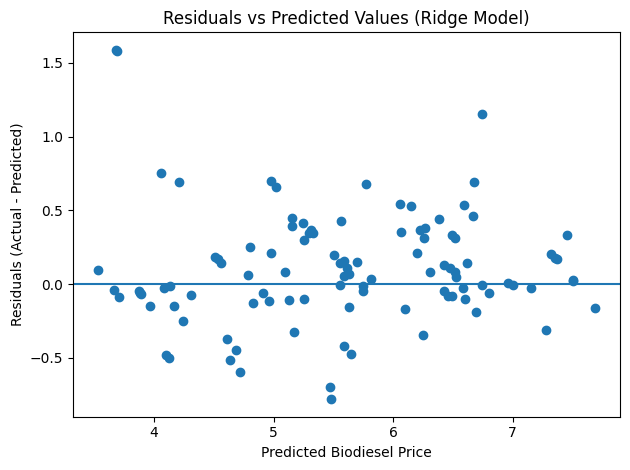

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Predictions
y_pred = best_ridge.predict(X_test)

# Residuals
residuals = y_test - y_pred

# Scatter plot
plt.figure()
plt.scatter(y_pred, residuals)

# Horizontal zero line
plt.axhline(0)

plt.title("Residuals vs Predicted Values (Ridge Model)")
plt.xlabel("Predicted Biodiesel Price")
plt.ylabel("Residuals (Actual - Predicted)")
plt.tight_layout()
plt.show()


From the above residual scatter plots from the Ridge Model, residuals are approximately centered around zero with no strong systematic pattern across predicted values, indicating that the Ridge model captures the dominant linear relationships and does not exhibit strong bias. A small number of outliers remain, consistent with episodic market shocks that are difficult to explain using cost and macro drivers alone..

In [ ]:
# Check Basic Residual Statistics
print("Mean residual:", np.mean(residuals))
print("Std residual:", np.std(residuals))
print("Min residual:", np.min(residuals))
print("Max residual:", np.max(residuals))

Mean residual: 0.10735863511613568
Std residual: 0.3877048225346222
Min residual: -0.7804599901306792
Max residual: 1.5878487243104251


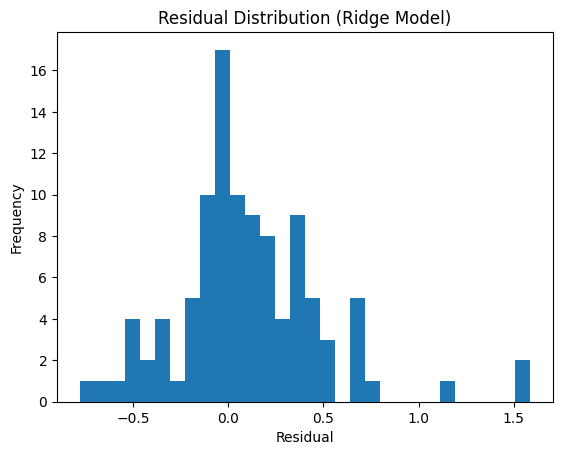

In [ ]:
# Plot Histogram
plt.figure()
plt.hist(residuals, bins=30)
plt.title("Residual Distribution (Ridge Model)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

The residual distribution appears approximately centered around zero with a moderately symmetric shape, suggesting that the model does not exhibit systematic bias. While minor right-skewness is observed due to occasional positive outliers, these likely reflect short-term market shocks rather than structural misspecification. Overall, the residual pattern supports the adequacy of the regularized linear modeling framework.

In [ ]:
print("Mean residual:", residuals.mean())
print("Skewness:", residuals.skew())
print("Kurtosis:", residuals.kurtosis())

Mean residual: 0.10735863511613568
Skewness: 1.0167104529839521
Kurtosis: 3.157747601169347


Residual diagnostics indicate a small positive mean error (0.107), suggesting mild underprediction bias. Skewness of 1.02 and kurtosis of 3.16 indicate right-skewed, fat-tailed error distribution. This implies that while the model performs well during stable periods, it underestimates occasional upward price shocks. Such behavior is consistent with the volatile and shock-prone nature of commodity markets.

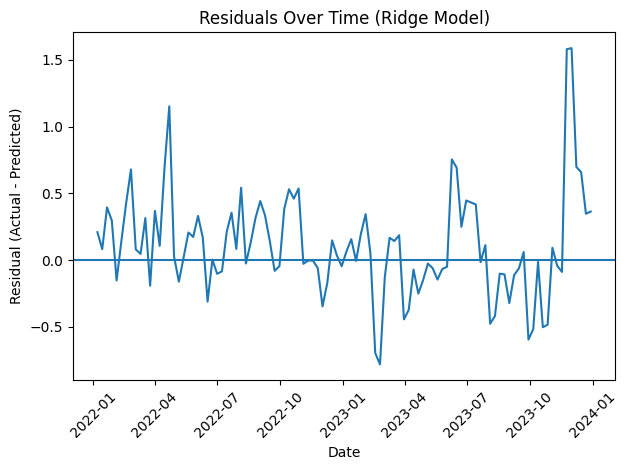

Lengths -> y_test: 103 y_pred: 103 residuals: 103


In [ ]:
# Plotting Residuals Over Time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Predict (make sure y_pred becomes a Series with the SAME index as y_test)
y_pred = pd.Series(best_ridge.predict(X_test), index=y_test.index, name="y_pred")

# Residuals as a Series (keeps index)
residuals = (y_test - y_pred).rename("residuals")

# Plot residuals over time (guaranteed same length)
plt.figure()
plt.plot(residuals.index, residuals.values)
plt.axhline(0)
plt.title("Residuals Over Time (Ridge Model)")
plt.xlabel("Date")
plt.ylabel("Residual (Actual - Predicted)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Lengths -> y_test:", len(y_test), "y_pred:", len(y_pred), "residuals:", len(residuals))

The residuals plotted over time appear largely centered around zero without a persistent upward or downward trend, indicating that the model adequately captures the underlying time persistence of biodiesel prices. While some clustering of residuals is observed during specific periods—particularly in recent years—these likely reflect market shocks or volatility regime changes rather than systematic model bias. Overall, no strong evidence of structural misspecification is detected.

In [ ]:
print("Train range:", X_train.index.min(), "to", X_train.index.max())
print("Test range:", X_test.index.min(), "to", X_test.index.max())
print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train range: 2007-05-11 00:00:00 to 2021-12-31 00:00:00
Test range: 2022-01-07 00:00:00 to 2023-12-29 00:00:00
Train size: 761
Test size: 103


# XGBoost Model

Having attempted a regression model, XG Boost was attempted as the 2nd Model for comparison as a test of the dataset's fit in a decision tree based model.

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)
mape_xgb = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100

print("XGBoost RMSE:", rmse_xgb)
print("XGBoost R²:", r2_xgb)
print("XGBoost MAPE:", mape_xgb)

XGBoost RMSE: 0.8836550720157058
XGBoost R²: 0.4014780387823482
XGBoost MAPE: 11.597516110280914


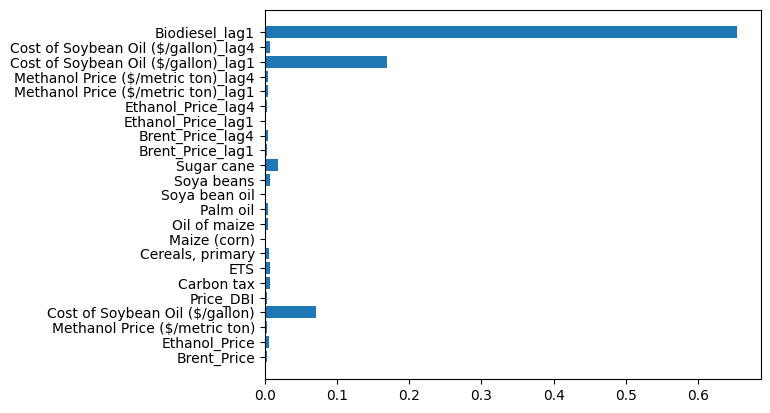

In [ ]:
import matplotlib.pyplot as plt

importance = xgb.feature_importances_
plt.barh(X_train.columns, importance)
plt.show()

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist",
    n_estimators=2000
)

param_dist = {
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 7],
    "min_child_weight": [1, 3, 5, 10, 15],
    "subsample": [0.6, 0.75, 0.85, 1.0],
    "colsample_bytree": [0.6, 0.75, 0.85, 1.0],
    "gamma": [0, 0.1, 0.3, 1, 3],
    "reg_alpha": [0, 1e-3, 1e-2, 0.1, 1],
    "reg_lambda": [0.5, 1, 2, 5, 10],
}

search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=40,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

best_params = search.best_params_
print("Best params:", best_params)
print("Best CV RMSE:", -search.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'subsample': 0.75, 'reg_lambda': 0.5, 'reg_alpha': 0.001, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.75}
Best CV RMSE: 0.2468638945131104


In [ ]:
best_xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist",
    n_estimators=2000,
    eval_metric="rmse",
    **best_params
)

best_xgb.fit(X_train, y_train)

y_pred = best_xgb.predict(X_test)

In [ ]:
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred))
r2_xgb = r2_score(y_test, y_pred)
print("XGB Test RMSE:", rmse_xgb)
print("XGB Test R²:", r2_xgb)
print("Baseline Test R²:", r2_base)

XGB Test RMSE: 0.9013200601356937
XGB Test R²: 0.3773089620276904
Baseline Test R²: 0.8369329281835884


Despite Fine tuning the XG boost model, Ridge proves to be the better regression model in predicting the price of biodiesal  1 week later. The best model of XG boost is in fact worst than the naive model hence proving that the datapoint does not follow a non-linear trend and follows better a linear trend.

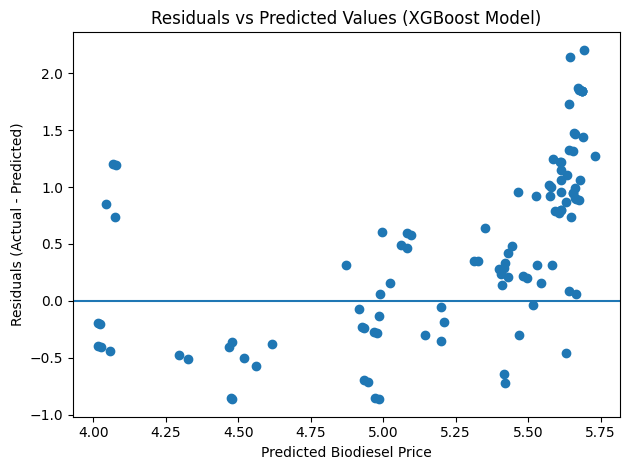

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Predictions
y_pred = best_xgb.predict(X_test)

# Residuals
residuals = y_test - y_pred

# Scatter plot
plt.figure()
plt.scatter(y_pred, residuals)

# Horizontal zero line
plt.axhline(0)

plt.title("Residuals vs Predicted Values (XGBoost Model)")
plt.xlabel("Predicted Biodiesel Price")
plt.ylabel("Residuals (Actual - Predicted)")
plt.tight_layout()
plt.show()


The residuals vs predicted values plot for the XGBoost model reveals systematic underprediction at higher price levels and increasing error variance as predicted prices rise. This indicates heteroskedasticity and structural bias in the nonlinear model specification. In contrast to the Ridge model, the tree-based approach appears less capable of capturing the highly persistent and linear nature of biodiesel price formation.

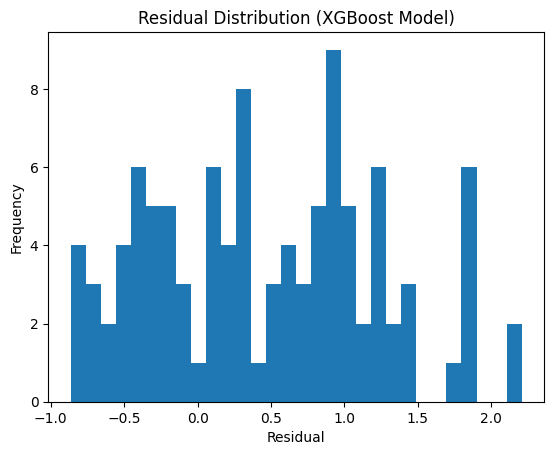

In [ ]:
plt.figure()
plt.hist(residuals, bins=30)
plt.title("Residual Distribution (XGBoost Model)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

The residual distribution of the XGBoost model exhibits noticeable right skewness and heavier tails, indicating systematic underprediction during higher price regimes and greater sensitivity to volatility spikes. Compared to the Ridge model, the nonlinear tree-based specification demonstrates larger dispersion and structural bias, reinforcing the conclusion that biodiesel price dynamics are better characterized by a regularized linear regression.

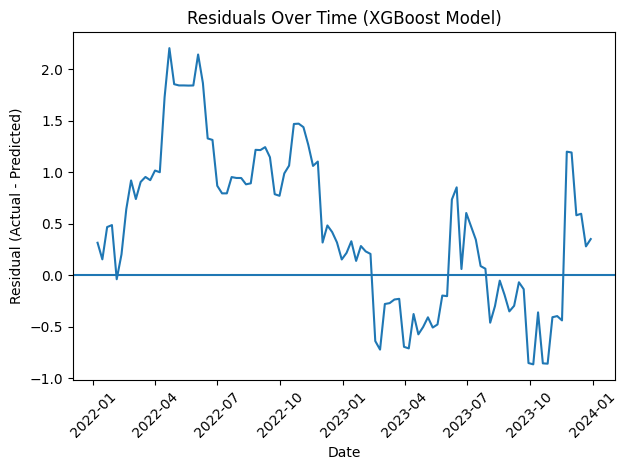

Lengths -> y_test: 103 y_pred: 103 residuals: 103


In [ ]:
# Plotting Residuals Over Time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Predict (make sure y_pred becomes a Series with the SAME index as y_test)
y_pred = pd.Series(best_xgb.predict(X_test), index=y_test.index, name="y_pred")

# Residuals as a Series (keeps index)
residuals = (y_test - y_pred).rename("residuals")

# Plot residuals over time (guaranteed same length)
plt.figure()
plt.plot(residuals.index, residuals.values)
plt.axhline(0)
plt.title("Residuals Over Time (XGBoost Model)")
plt.xlabel("Date")
plt.ylabel("Residual (Actual - Predicted)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Lengths -> y_test:", len(y_test), "y_pred:", len(y_pred), "residuals:", len(residuals))

The residuals-over-time chart shows that the XGBoost model does not make random small mistakes. Instead, it makes similar types of errors for several weeks in a row. In 2022, the model mostly underestimated prices, while in early 2023 it tended to overestimate them. Toward late 2023, the size of the errors increased, showing that the model became less stable during more volatile market conditions. This suggests that XGBoost has difficulty adapting when the biodiesel market shifts, especially during periods of rapid change.
As compared to the Ridge model, XGBoost is unable to adapt when market conditions become more volatile. Hence, validating the theory that Tree based Model is unsuitable for the Commodity Price prediction market.

# Elastic Net predictive model

The Elastic Net model is a linear regression technique that combines 
 (Lasso) and 
 (Ridge) regularization methods to improve prediction accuracy and handle multicollinearity. By adding both penalties to the loss function, it performs feature selection while keeping correlated variables together, making it more robust than Lasso alone when features are highly correlated

In [ ]:
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

enetcv = Pipeline([
    ("scaler", StandardScaler()),
    ("enet", ElasticNetCV(
        l1_ratio=np.linspace(0, 1, 21),
        alphas=np.logspace(-6, 1, 80),
        cv=tscv,
        max_iter=50000,
        n_jobs=-1,
        random_state=42
    ))
])

enetcv.fit(X_train, y_train)
pred = enetcv.predict(X_test)

print("Chosen l1_ratio:", enetcv.named_steps["enet"].l1_ratio_)
print("Chosen alpha   :", enetcv.named_steps["enet"].alpha_)
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("Test R²:", r2_score(y_test, pred))
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

enetcv = Pipeline([
    ("scaler", StandardScaler()),
    ("enet", ElasticNetCV(
        l1_ratio=np.linspace(0, 1, 21),
        alphas=np.logspace(-6, 1, 80),
        cv=tscv,
        max_iter=50000,
        n_jobs=-1,
        random_state=42
    ))
])

enetcv.fit(X_train, y_train)
pred = enetcv.predict(X_test)

print("Chosen l1_ratio:", enetcv.named_steps["enet"].l1_ratio_)
print("Chosen alpha   :", enetcv.named_steps["enet"].alpha_)
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("Test R²:", r2_score(y_test, pred))

Chosen l1_ratio: 1.0
Chosen alpha   : 0.03303599120128339
Test RMSE: 0.43890782421698676
Test R²: 0.85234057020972
Chosen l1_ratio: 1.0
Chosen alpha   : 0.03303599120128339
Test RMSE: 0.43890782421698676
Test R²: 0.85234057020972


#### Comparing Results Between Elastic Net Model and Baseline Model

In [ ]:
# Comparing Elastic Net Model against 
Elasticnet_comparison=round((baseline_rmse-np.sqrt(mean_squared_error(y_test, pred))) / baseline_rmse * 100,2)

print("Test RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("Test R²:", r2_score(y_test, pred))
print("Baseline RMSE:", baseline_rmse)
print("Baseline Test R²:", r2_base)
print("Elastic Net to Baseline RMSE performance:",Elasticnet_comparison,"%")


Test RMSE: 0.43890782421698676
Test R²: 0.85234057020972
Baseline RMSE: 0.4612388341585325
Baseline Test R²: 0.8369329281835884
Elastic Net to Baseline RMSE performance: 4.84 %


Elastic Net Model also fair pretty well for the data set and is better than the baseline model by about 4.84% where the ridge model performs much better at about 13.1%

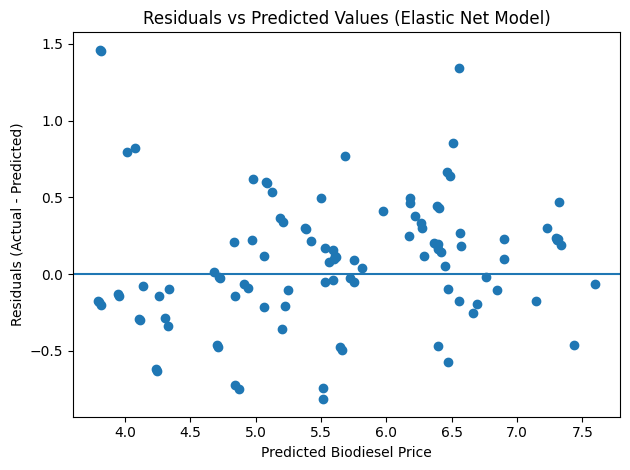

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Predictions
y_pred = enetcv.predict(X_test)

# Residuals
residuals = y_test - y_pred

# Scatter plot
plt.figure()
plt.scatter(y_pred, residuals)

# Horizontal zero line
plt.axhline(0)

plt.title("Residuals vs Predicted Values (Elastic Net Model)")
plt.xlabel("Predicted Biodiesel Price")
plt.ylabel("Residuals (Actual - Predicted)")
plt.tight_layout()
plt.show()

The Elastic Net model appears reasonably stable and well-calibrated. Errors are mostly random and centered around zero, with only moderate dispersion at extreme price levels. Compared to more volatile models (like XGBoost), this indicates stronger consistency and better handling of the persistent linear structure in biodiesel prices

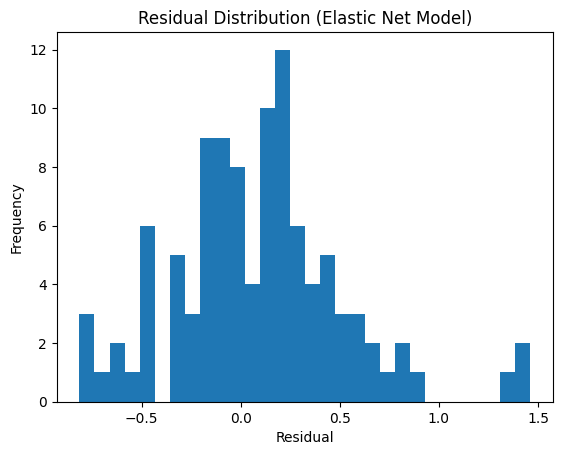

In [ ]:
plt.figure()
plt.hist(residuals, bins=30)
plt.title("Residual Distribution (Elastic Net Model)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

The Elastic Net model produces errors that are mostly small and centered around zero, indicating stable and reliable performance. While there are a few larger underprediction cases, the overall distribution suggests that the model captures the core structure of biodiesel price movements reasonably well. However, in terms of the Rsquare statistics, the Ridge model still performs better in its prediction accuracy.

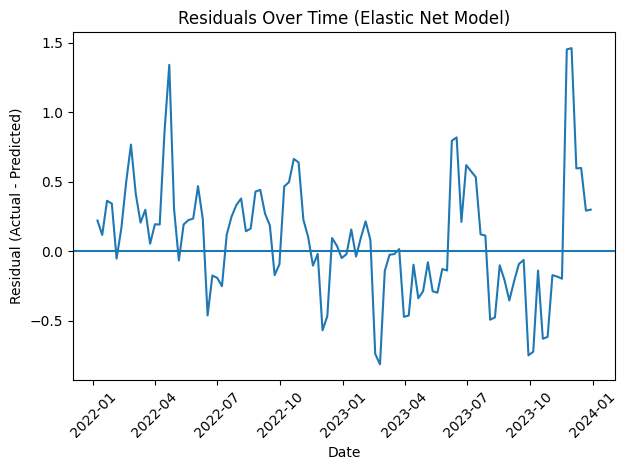

Lengths -> y_test: 103 y_pred: 103 residuals: 103


In [ ]:
# Plotting Residuals Over Time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Predict (make sure y_pred becomes a Series with the SAME index as y_test)
y_pred = pd.Series(enetcv.predict(X_test), index=y_test.index, name="y_pred")

# Residuals as a Series (keeps index)
residuals = (y_test - y_pred).rename("residuals")

# Plot residuals over time (guaranteed same length)
plt.figure()
plt.plot(residuals.index, residuals.values)
plt.axhline(0)
plt.title("Residuals Over Time (Elastic Net Model)")
plt.xlabel("Date")
plt.ylabel("Residual (Actual - Predicted)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Lengths -> y_test:", len(y_test), "y_pred:", len(y_pred), "residuals:", len(residuals))

The Elastic Net model performs quite steadily over time. Most of its prediction errors are small and stay close to zero, which means it usually predicts prices fairly accurately. There are some periods where the errors move in the same direction for a few weeks, especially when the market changes quickly. However, the size of these mistakes does not become extreme. Compared to more complex nonlinear models, Elastic Net gives more consistent and reliable results, although it still finds it harder to predict during very volatile market periods.

# SARIMAX Modeling

As Arimax work best with high freuency data to capture trends movement, data such as the commodity harvvest variable will need to be excluded as they are calculated on a yearly basis

In [ ]:
exog_cols = [
    "Brent_Price",
    "Ethanol_Price",
    "Methanol Price ($/metric ton)",
    "Cost of Soybean Oil ($/gallon)",
    "Price_DBI",
    "Carbon tax",
    "ETS"
]

X_sarimax = X[exog_cols]

Split X dataset again for SARIMAX Modeling

In [ ]:
final_variables.info()

<class 'pandas.DataFrame'>
RangeIndex: 864 entries, 4 to 867
Data columns (total 26 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Date                                 864 non-null    datetime64[us]
 1   Brent_Price                          864 non-null    float64       
 2   Ethanol_Price                        864 non-null    float64       
 3   Biodiesel_Price ($/gallon) IA-USDA   864 non-null    float64       
 4   Methanol Price ($/metric ton)        864 non-null    int64         
 5   Cost of Soybean Oil ($/gallon)       864 non-null    float64       
 6   Price_DBI                            864 non-null    float64       
 7   Carbon tax                           864 non-null    float64       
 8   ETS                                  864 non-null    float64       
 9   Cereals, primary                     864 non-null    float64       
 10  Maize (corn)             

In [ ]:
# Try SARIMAX again with y_next instead of Y
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, r2_score

df_s = final_variables.sort_values("Date").copy()
df_s["Date"] = pd.to_datetime(df_s["Date"])
df_s = df_s.set_index("Date")
df_s = df_s[~df_s.index.duplicated(keep="first")].sort_index()


df_s = df_s.asfreq("W-FRI")

print("freq:", df_s.index.freq)
print("inferred:", df_s.index.inferred_freq)

y_col = "Biodiesel_Price ($/gallon) IA-USDA"

# Target = next week biodiesel
df_s["y_next"] = df_s[y_col].shift(-1)

# Proper 1-week lag of biodiesel (known at time t)
df_s["Biodiesel_lag1"] = df_s[y_col].shift(1)

# Exogenous drivers (weekly)
exog_cols = [
    "Brent_Price",
    "Methanol Price ($/metric ton)",
    "Cost of Soybean Oil ($/gallon)",
    "Carbon tax",
    "ETS",
    "Price_DBI"
]

# Lag exog drivers by 1 week (known at time t)
for c in exog_cols:
    df_s[c + "_lag1"] = df_s[c].shift(1)

# Final exog set (ARX)
X_cols = ["Biodiesel_lag1"] + [c + "_lag1" for c in exog_cols]

# Drop NaNs
df_s = df_s.dropna(subset=["y_next"] + X_cols)

y = df_s["y_next"]
X = df_s[X_cols]

# Split
split = int(len(df_s) * 0.88)
y_train, y_test = y.iloc[:split], y.iloc[split:]
X_train, X_test = X.iloc[:split], X.iloc[split:]

# ARX regression form first (stable)
model = SARIMAX(
    y_train,
    exog=X_train,
    order=(0, 0, 0),
    seasonal_order=(0, 0, 0, 0),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
)

res = model.fit(disp=False)

pred = res.get_forecast(steps=len(y_test), exog=X_test).predicted_mean

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("SARIMAX ARX (y_next) Test RMSE:", rmse)
print("SARIMAX ARX (y_next) Test R²  :", r2)

freq: <Week: weekday=4>
inferred: W-FRI


c:\Users\user\anaconda3\envs\py312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\user\anaconda3\envs\py312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


SARIMAX ARX (y_next) Test RMSE: 0.445505341322139
SARIMAX ARX (y_next) Test R²  : 0.8498762703621507


c:\Users\user\anaconda3\envs\py312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\user\anaconda3\envs\py312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\user\anaconda3\envs\py312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
print(res.params.sort_values(key=np.abs, ascending=False))

Biodiesel_lag1                         0.89
Cost of Soybean Oil ($/gallon)_lag1    0.09
sigma2                                 0.03
intercept                              0.00
Brent_Price_lag1                       0.00
ETS_lag1                              -0.00
Carbon tax_lag1                        0.00
Methanol Price ($/metric ton)_lag1    -0.00
Price_DBI_lag1                         0.00
dtype: float64


### Evaluation of the SARIMAX Model: 

While SARIMAX is theoretically well-suited for time-series modeling, it is sensitive to multicollinearity and lacks regularization. Given the severe collinearity among:

1. Soybean oil measures

2. Brent and ethanol prices

3. Carbon tax and ETS

Maximum likelihood estimation becomes unstable.

**Ridge regression, by contrast:**

1. Penalizes coefficient magnitude

2. Handles correlated predictors effectively

3. Directly optimizes predictive performance

Therefore, Ridge is statistically more robust in this high-dimensional, collinear commodity pricing environment.

# Overall Model Evaluation Across: Baseline, Ridge, Tree Based Models, Elastic  Net and SARIMAX

Across all models evaluated, the empirical results show consistency in indicatingg that weekly biodiesel prices are characterized by strong short-term persistence and a predominantly linear cost-driven structure. The naïve lag benchmark alone achieved relatively high explanatory power, confirming that current price levels contain substantial information about next week’s price. However, among all tested specifications, Ridge regression delivered the strongest predictive performance, achieving the lowest RMSE and highest R² on the test set.

The superiority of Ridge regression reflects the structural properties of the dataset. Biodiesel prices are highly autoregressive and exhibit substantial multicollinearity across input cost variables, energy prices, and policy-related indicators. While the SARIMAX (ARX) framework successfully confirmed the underlying autoregressive structure and highlighted soybean oil cost as the most economically meaningful external driver, its lack of regularization made it more sensitive to multicollinearity and parameter instability. Similarly, tree-based ensemble models underperformed, suggesting that nonlinear interactions are not the dominant mechanism governing weekly biodiesel price movements.

Overall, the evidence supports the characterization of biodiesel price formation as a highly persistent, input-cost-driven linear process. In such an environment, regularized linear regression specifically Ridge regression offers the most robust and accurate forecasting framework by stabilizing coefficient estimates while preserving economically relevant signal. Therefore, Ridge regression is selected as the final winning model for weekly biodiesel price prediction.